In [ ]:
import numpy as np
from pandas.conftest import observed
%reload_ext autoreload
%autoreload 2

In [525]:
import pandas as pd

from src import (
    mappings,
)

from persistence import datasets as dataset_persistence

from src.rna import preprocessing as rna_preprocessing
from src.adt import preprocessing as adt_preprocessing

from src.logs import get_logger

log = get_logger()

LEVEL = "celltype.l2"

In [537]:
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.simplefilter("ignore", category=PerformanceWarning)
warnings.simplefilter("ignore", category=ImplicitModificationWarning)


In [528]:
# Load the persistence
dataset = dataset_persistence.load_or_create_subsample(subsample_size=10_000,
                                                       level=LEVEL)
rna_dataset, adt_dataset = dataset["rna"], dataset["adt"]

In [531]:
# QC
rna_preprocessing.calculate_qc_metrics_in_place(rna_dataset)

In [532]:
# Normalize
rna_preprocessing.normalize_in_place(rna_dataset)
adt_preprocessing.normalize_in_place(adt_dataset)

In [533]:
# Feature selection

# HV Genes
rna_preprocessing.annotate_highly_variable_genes(rna_dataset)
hv_genes = rna_preprocessing.get_highly_variable_genes(rna_dataset)

protein_names = adt_dataset.var["protein_name"]
marker_genes_for_proteins = mappings.get_marker_genes_for_proteins(
    protein_names)
expressed_genes = rna_dataset.var["gene_name"]

expressed_marker_genes_for_proteins = (marker_genes_for_proteins
                                       .intersection(expressed_genes))

genes_of_interest = expressed_marker_genes_for_proteins.union(hv_genes)

genes_of_interest_mask = rna_dataset.var["gene_name"].isin(
    sorted(genes_of_interest))
rna_of_interest_dataset = rna_dataset[:, genes_of_interest_mask].copy()

In [534]:
# Filtering
rna_of_interest_dataset = rna_preprocessing.apply_basic_filtering(
    rna_of_interest_dataset)

In [538]:
# Scaling
rna_preprocessing.scale_in_place(rna_of_interest_dataset)

# Dependency measures

## 1. Linear marginal - spearman

In [541]:
rna_preprocessing.rank_transform_in_place(rna_of_interest_dataset)

In [542]:
from measures.linear.marginal import spearman_correlation
from rna.preprocessing import LAYER_NAME_RANK_TRANSFORMED

data_df = pd.DataFrame(
    data=rna_of_interest_dataset.layers[LAYER_NAME_RANK_TRANSFORMED],
    index=rna_of_interest_dataset.obs_names,
    columns=rna_of_interest_dataset.var["gene_name"])

target_df = rna_preprocessing.build_target_matrix(rna_of_interest_dataset,
                                                  LEVEL)
spearman_results_df = spearman_correlation.calculate_scores(
    expression_levels_df=data_df,
    labeling_df=target_df
)

In [660]:
from measures.linear.conditional import ledoit_wolf_partial_correlation

lw_df = ledoit_wolf_partial_correlation.calculate_scores(
    expression_levels_df=data_df,
    labeling_df=target_df
)

In [477]:
from src import ground_truth

driver_gene_ground_truth = ground_truth.build_ground_truth(
    adt_dataset, LEVEL, genes_of_interest)



## Result evaluation / intuition

Before we dive into the formal driver-recovery analysis (AUC_rel) let us look at the results
and try to develop an intuition about its quality.

### Heatmap validation

In [630]:
from measures.validation import heatmap as heatmap_validation

spearman_heatmap_results_df = heatmap_validation.calculate_validation_data(spearman_results_df)
heatmap_validation.plot(spearman_heatmap_results_df, rna_of_interest_dataset, LEVEL)

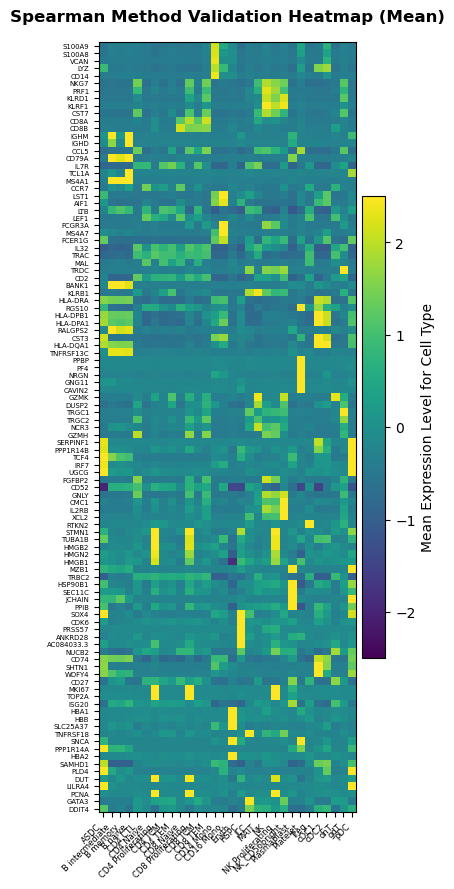

In [661]:
leodit_wolf_heatmap_results_df = heatmap_validation.calculate_validation_data(lw_df)
heatmap_validation.plot(leodit_wolf_heatmap_results_df, rna_of_interest_dataset, LEVEL)

### Hit/miss validation

In [600]:
from measures.validation import hit_miss_rates as hit_miss_validation

spearman_hit_miss_validation_df = hit_miss_validation.calculate_validation_data(
    spearman_results_df, driver_gene_ground_truth)

lf_hit_miss_validation_df = hit_miss_validation.calculate_validation_data(lw_df,
                                                                          driver_gene_ground_truth)

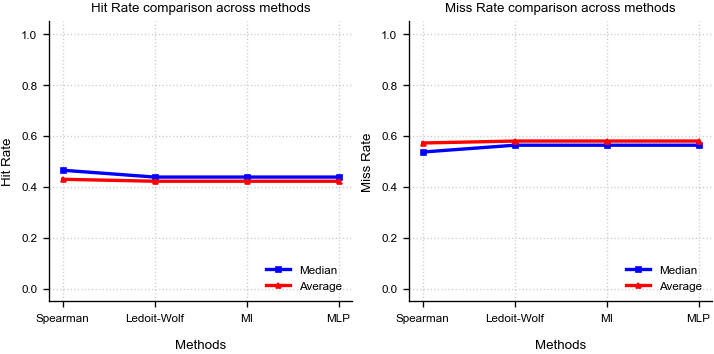

In [601]:
names = ["Spearman", "Ledoit-Wolf", "MI", "MLP"]
summaries = [spearman_hit_miss_validation_df, lf_hit_miss_validation_df,
             lf_hit_miss_validation_df, lf_hit_miss_validation_df]

hit_miss_validation.plot(summaries, names)


## Formal method comparison

rank-based driver-recovery metric of CellRank 2 (AUC_rel)
